In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [282]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')


In [283]:
sample = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')

In [284]:
with open("/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt", "r") as f:
    text = f.read()

In [285]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [286]:
train.shape

(1460, 81)

## EDA

In [287]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='SalePrice', ylabel='Count'>

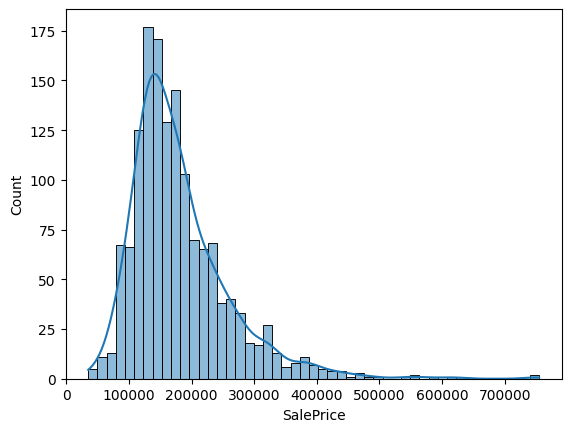

In [288]:
sns.histplot(train['SalePrice'],kde=True)

<Axes: ylabel='SalePrice'>

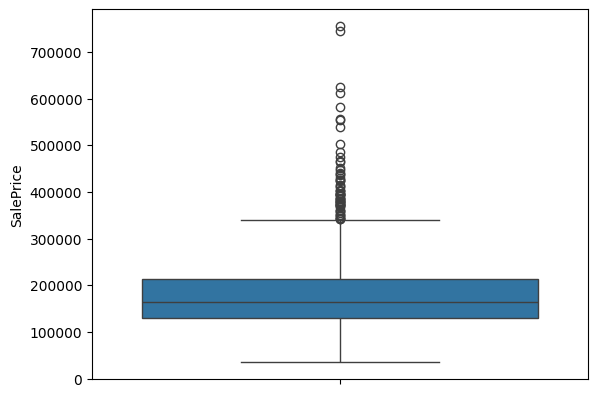

In [289]:
sns.boxplot(train['SalePrice'])

<Axes: xlabel='BldgType', ylabel='LotArea'>

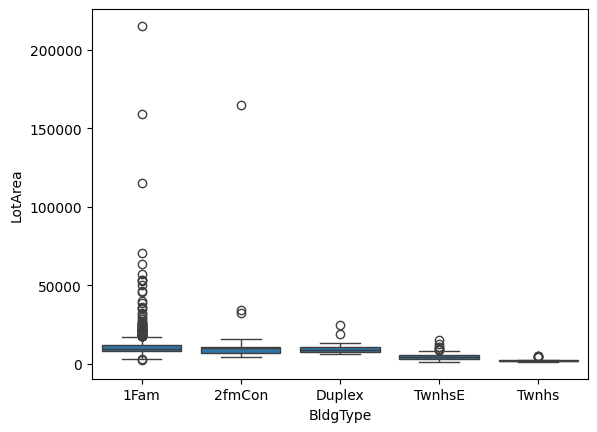

In [290]:
sns.boxplot(
    x="BldgType",
    y="LotArea",
    data=train
)

In [291]:
corr = train.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

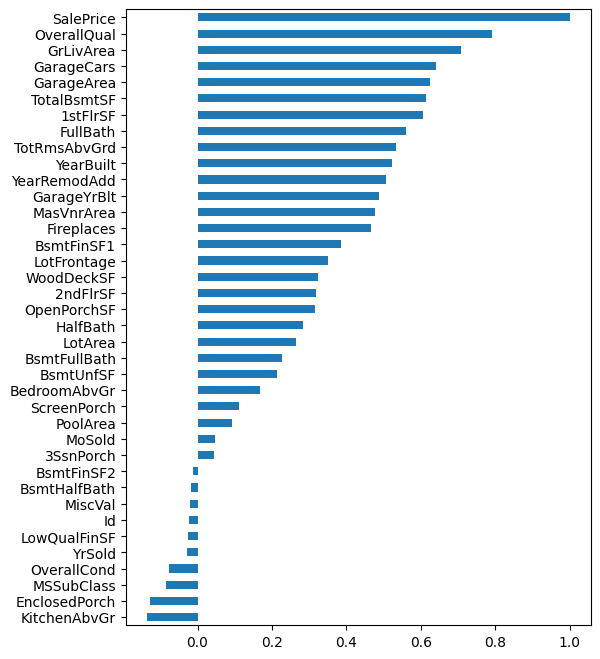

In [292]:
plt.figure(figsize=(6,8))

corr["SalePrice"].sort_values().plot(kind="barh")

plt.show()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

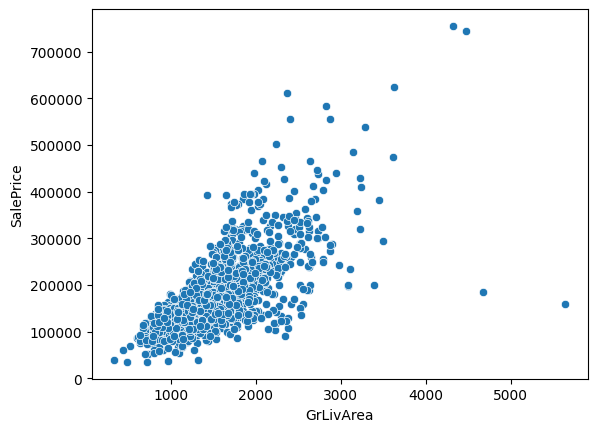

In [293]:
sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=train
)

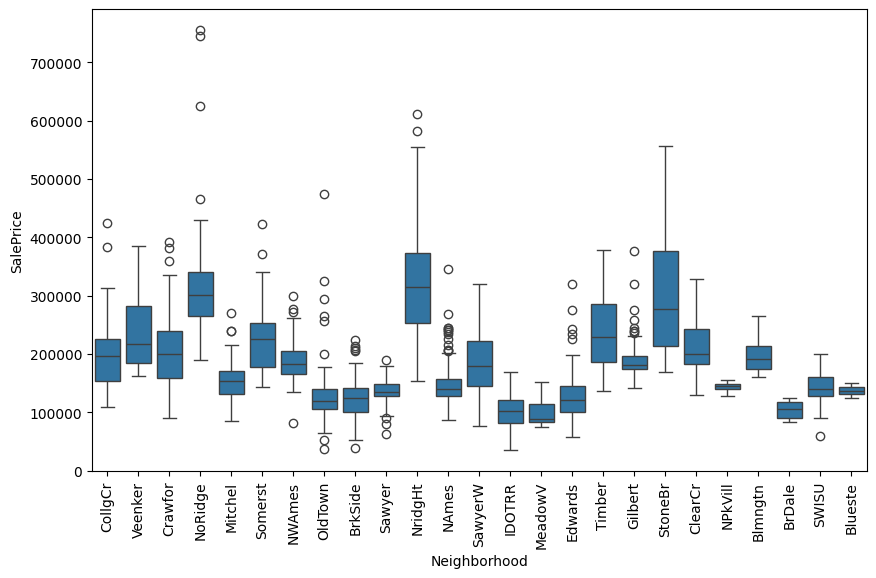

In [294]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=train
)

plt.xticks(rotation=90)

plt.show()

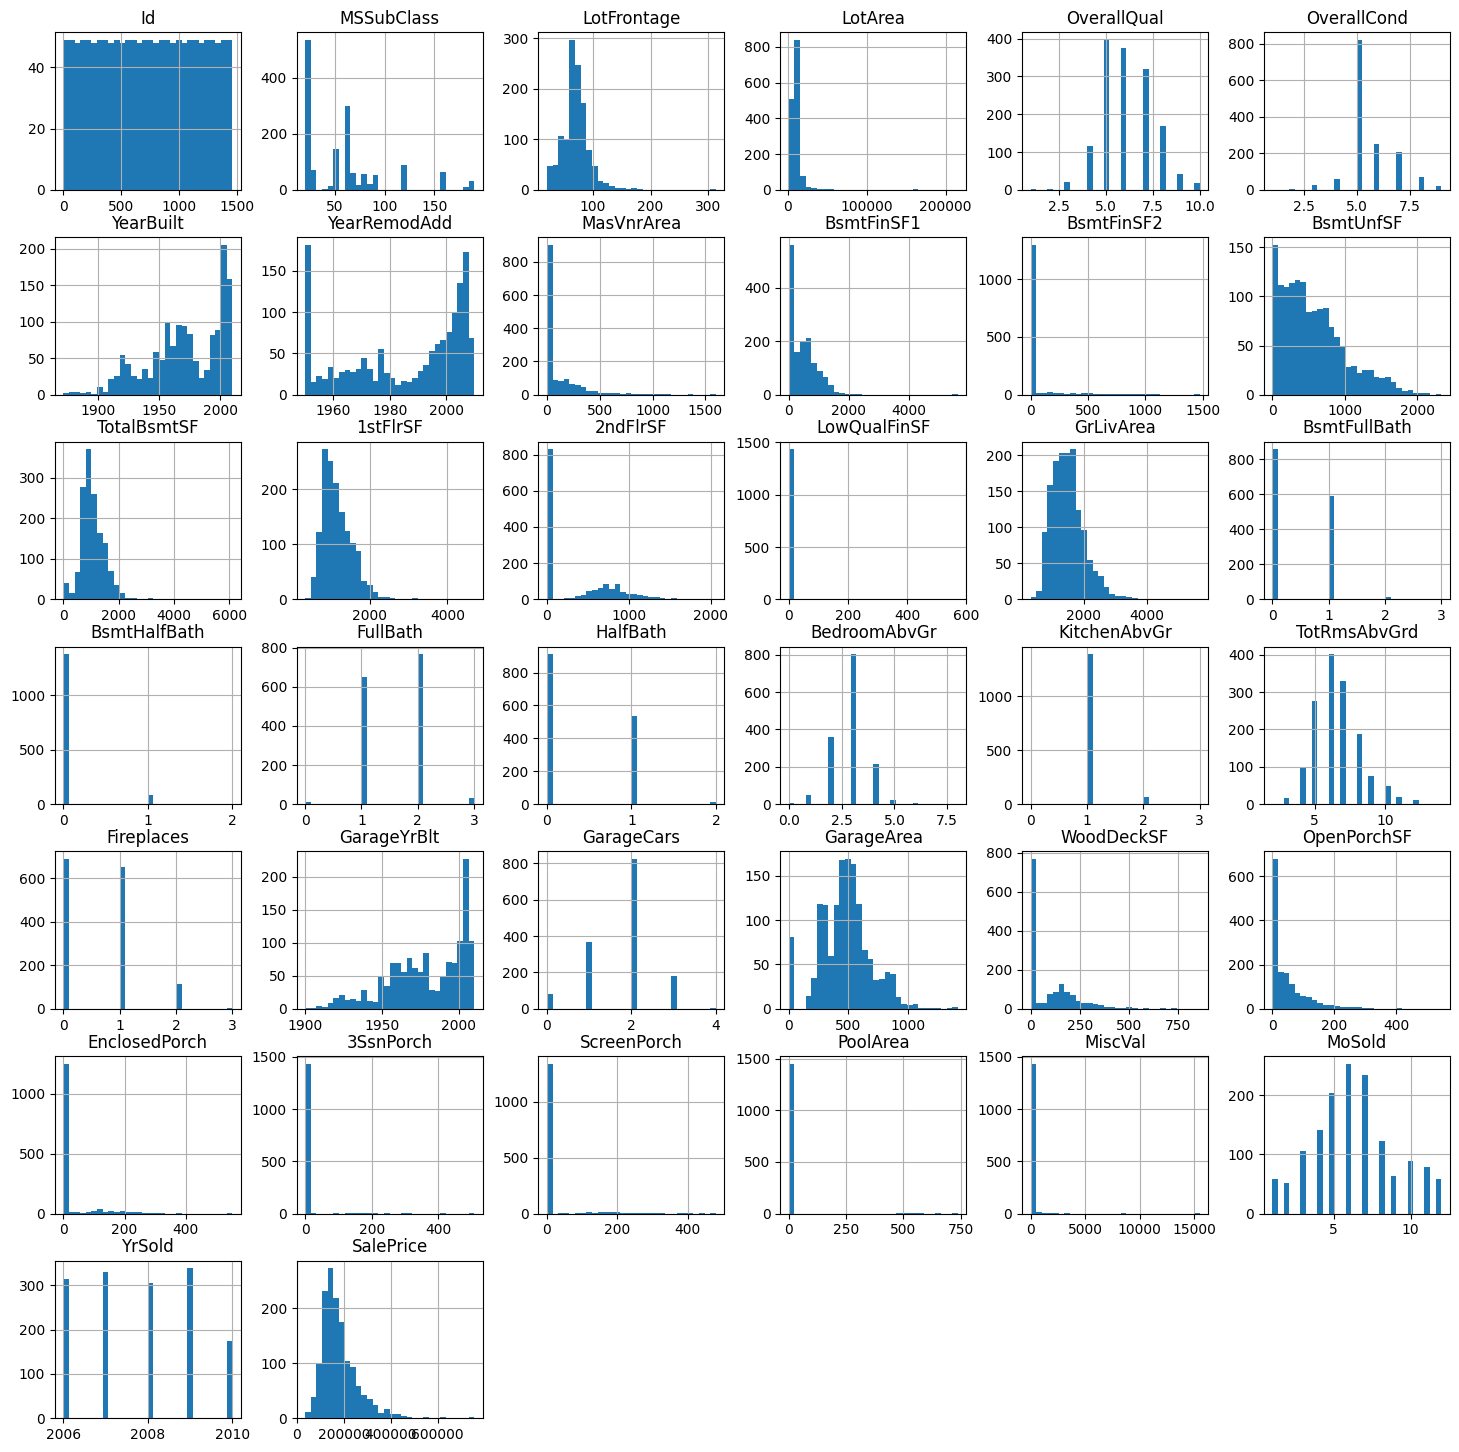

In [295]:
train.hist(
    figsize=(18,18),
    bins=30
)

plt.show()

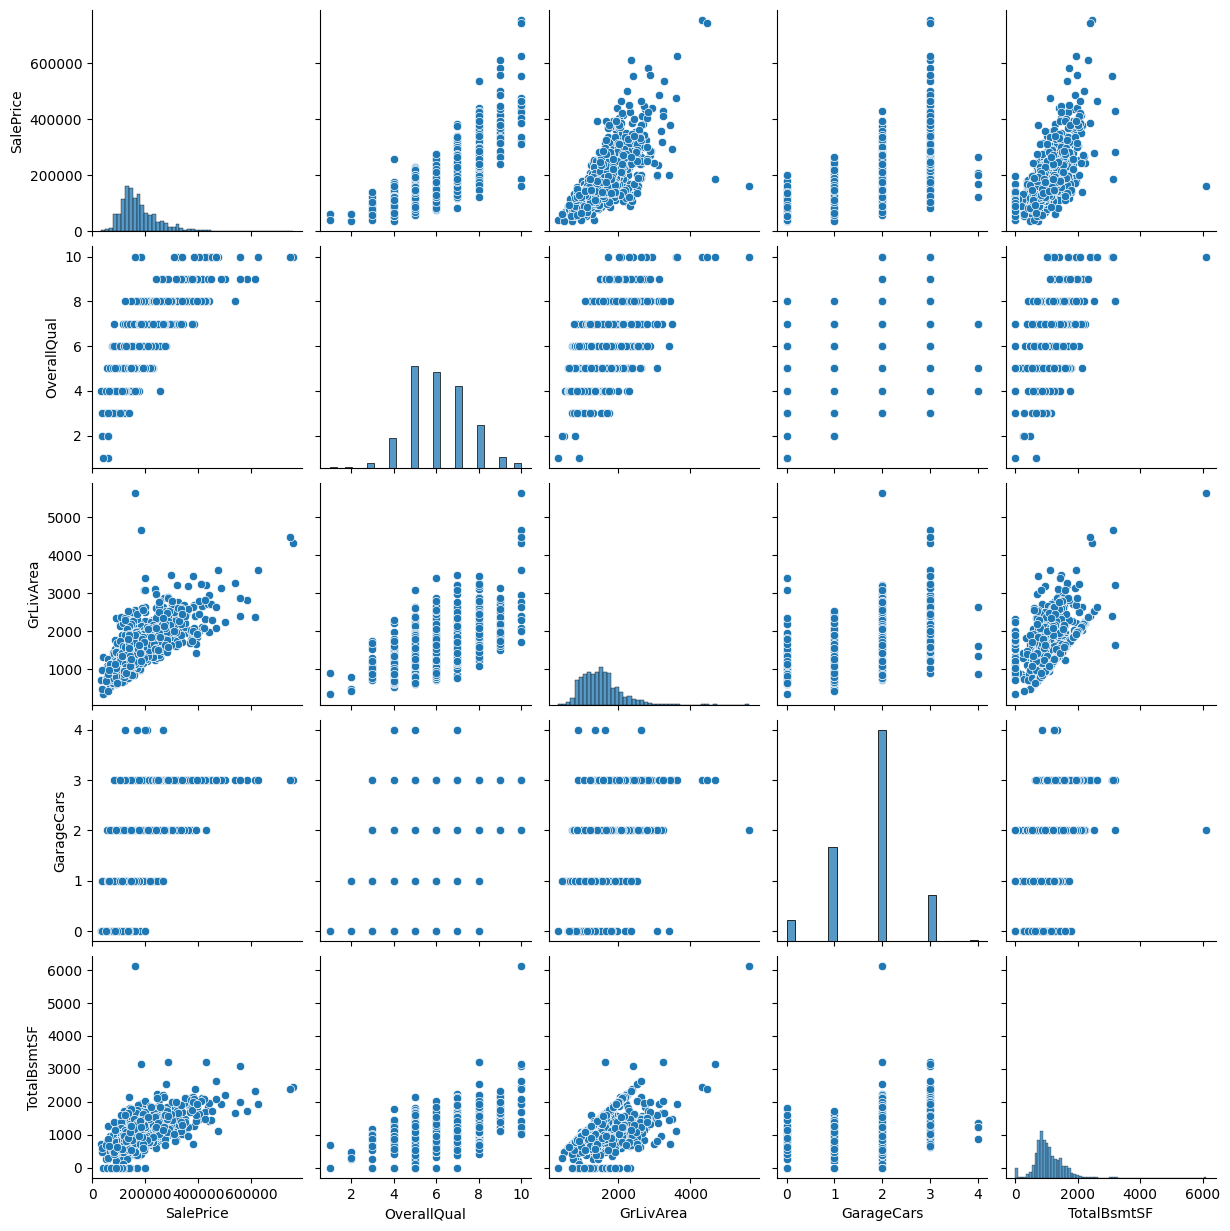

In [296]:
cols = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

sns.pairplot(train[cols])

plt.show()

## Filling nulls

In [297]:
missing = (
    train.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [298]:
y = train["SalePrice"]

train = train.drop(columns="SalePrice")

df = pd.concat([train, test], ignore_index=True)

In [299]:
df.shape

(2919, 80)

In [300]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    df[col] = df[col].fillna("None")

In [301]:
zero_cols = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    df[col] = df[col].fillna(0)

In [302]:
df["LotFrontage"] = (
    df.groupby("Neighborhood")["LotFrontage"]
      .transform(lambda x: x.fillna(x.median()))
)

In [303]:
mode_cols = [
    "Electrical",
    "MSZoning",
    "KitchenQual",
    "Exterior1st",
    "Exterior2nd",
    "SaleType",
    "Utilities"
]

for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [304]:
df["Functional"] = df["Functional"].fillna("Typ")

In [305]:
df.isnull().sum().sort_values(ascending=False).head()

Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
dtype: int64

## Ordinal Encoding

In [306]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

In [307]:
quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond"
]

for col in quality_cols:
    df[col] = df[col].map(quality_map)

In [308]:
lotshape_map = {
    "IR3":0,
    "IR2":1,
    "IR1":2,
    "Reg":3
}

df["LotShape"] = df["LotShape"].map(lotshape_map)

In [309]:
street_map = {
    "Grvl":0,
    "Pave":1
}

df["Street"] = df["Street"].map(street_map)

In [310]:
alley_map = {
    "None":0,
    "Grvl":1,
    "Pave":2
}

df["Alley"] = df["Alley"].map(alley_map)

In [311]:
paved_map = {
    "N":0,
    "P":1,
    "Y":2
}

df["PavedDrive"] = df["PavedDrive"].map(paved_map)

In [312]:
fence_map = {
    "None":0,
    "MnWw":1,
    "GdWo":2,
    "MnPrv":3,
    "GdPrv":4
}

df["Fence"] = df["Fence"].map(fence_map)

In [313]:
landslope_map = {
    "Sev":0,
    "Mod":1,
    "Gtl":2
}

df["LandSlope"] = df["LandSlope"].map(landslope_map)

In [314]:
functional_map = {
    "Sal":0,
    "Sev":1,
    "Maj2":2,
    "Maj1":3,
    "Mod":4,
    "Min2":5,
    "Min1":6,
    "Typ":7
}

df["Functional"] = df["Functional"].map(functional_map)

## One-Hot Encoding

In [315]:
df.select_dtypes(include="object").columns

Index(['MSZoning', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir',
       'Electrical', 'GarageType', 'GarageFinish', 'PoolQC', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [316]:
for col in df.select_dtypes(include="object").columns:
    print(col,df[col].nunique())

MSZoning 5
LandContour 4
Utilities 2
LotConfig 5
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 4
Foundation 6
BsmtExposure 5
BsmtFinType1 7
BsmtFinType2 7
Heating 6
CentralAir 2
Electrical 5
GarageType 7
GarageFinish 4
PoolQC 4
MiscFeature 5
SaleType 9
SaleCondition 6


In [317]:
df = pd.get_dummies(df, drop_first=False)

In [318]:
len(df.select_dtypes(include="object").columns)

0

In [319]:
df.isnull().sum().sum()

np.int64(0)

In [320]:
df.shape

(2919, 246)

## Feature Engineering

In [321]:
# Total basement area
df["TotalBsmtSF"] = (
    df["BsmtFinSF1"] +
    df["BsmtFinSF2"] +
    df["BsmtUnfSF"]
)

# Total house area
df["TotalSF"] = (
    df["1stFlrSF"] +
    df["2ndFlrSF"] +
    df["TotalBsmtSF"]
)

In [322]:
df["TotalBathrooms"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

df["YearsSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]

df["TotalPorchSF"] = (
    df["OpenPorchSF"] +
    df["EnclosedPorch"] +
    df["3SsnPorch"] +
    df["ScreenPorch"]
)

In [323]:
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

df["HasPool"] = (df["PoolArea"] > 0).astype(int)

df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

In [324]:
df["OverallScore"] = df["OverallQual"] * df["OverallCond"]

In [325]:
df.shape

(2919, 256)

In [326]:
df.isnull().sum().sum()

np.int64(0)

## Skewness Transformation

In [327]:
from scipy.stats import skew

In [328]:
numeric_features = df.select_dtypes(include=[np.number]).columns

In [329]:
skewness = df[numeric_features].apply(lambda x: skew(x.dropna()))

In [330]:
skewness = skewness.sort_values(ascending=False)

print(skewness.head(20))

MiscVal          21.947195
PoolArea         16.898328
HasPool          14.884318
LotArea          12.822431
LowQualFinSF     12.088761
3SsnPorch        11.376065
KitchenAbvGr      4.302254
BsmtFinSF2        4.146143
Alley             4.138385
EnclosedPorch     4.003891
ScreenPorch       3.946694
BsmtHalfBath      3.931594
MasVnrArea        2.613592
OpenPorchSF       2.535114
TotalPorchSF      2.237266
WoodDeckSF        1.842433
Fence             1.754829
TotalSF           1.511479
LotFrontage       1.505704
1stFlrSF          1.469604
dtype: float64


In [331]:
exclude_cols = [
    # Binary features
    "HasGarage",
    "HasPool",
    "HasFireplace",
    "HasBasement",

    # Ordinal / encoded categorical
    "OverallQual",
    "OverallCond",
    "KitchenQual",
    "HeatingQC",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "GarageQual",
    "GarageCond",
    "FireplaceQu",
    "PoolQC",
    "Fence",
    "Alley",

    # Time / count features
    "MoSold",
    "YrSold",
    "KitchenAbvGr",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars"
]

In [332]:
exclude_cols += [
    "MSSubClass",
    "Street",
    "LotShape",
    "LandSlope",
    "Functional",
    "PavedDrive"
]

In [333]:
exclude_cols += ["GarageYrBlt"]

In [334]:
numeric_features = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

skewness = df[numeric_features].apply(lambda x: skew(x.dropna()))

skewed_features = skewness[abs(skewness) > 0.75].index

df[skewed_features] = np.log1p(df[skewed_features])

In [335]:
print(f"Number of skewed features: {len(skewed_features)}")
print(skewed_features.tolist())

Number of skewed features: 20
['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'TotalPorchSF']


## Splitting back

In [336]:
n_train = len(train)  

X_train = df.iloc[:n_train].copy()
X_test = df.iloc[n_train:].copy()

In [337]:
y = np.log1p(y)

In [338]:
print(X_train.shape)
print(X_test.shape)
print(y.shape)

(1460, 256)
(1459, 256)
(1460,)


## Linear Regression Models

In [339]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

In [340]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [341]:
def evaluate_model(model, X, y, name):

    rmse = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            scoring="neg_mean_squared_error",
            cv=5,
            n_jobs=-1
        )
    )

    print("=" * 45)
    print(name)
    print(f"Mean RMSE : {rmse.mean():.5f}")
    print(f"Std RMSE  : {rmse.std():.5f}")

    return rmse

In [342]:
linear_rmse = evaluate_model(
    LinearRegression(),
    X_train_scaled,
    y,
    "Linear Regression"
)

ridge_rmse = evaluate_model(
    Ridge(alpha=10),
    X_train_scaled,
    y,
    "Ridge Regression"
)

lasso_rmse = evaluate_model(
    Lasso(
        alpha=0.0005,
        max_iter=10000
    ),
    X_train_scaled,
    y,
    "Lasso Regression"
)

elastic_rmse = evaluate_model(
    ElasticNet(
        alpha=0.0005,
        l1_ratio=0.9,
        max_iter=10000
    ),
    X_train_scaled,
    y,
    "ElasticNet"
)

Linear Regression
Mean RMSE : 0.14490
Std RMSE  : 0.02729
Ridge Regression
Mean RMSE : 0.13440
Std RMSE  : 0.01473
Lasso Regression
Mean RMSE : 0.13080
Std RMSE  : 0.01497
ElasticNet
Mean RMSE : 0.13109
Std RMSE  : 0.01492


In [343]:
results = {
    "Linear Regression": linear_rmse.mean(),
    "Ridge Regression": ridge_rmse.mean(),
    "Lasso Regression": lasso_rmse.mean(),
    "ElasticNet": elastic_rmse.mean()
}

print("=" * 45)
print("Model Comparison")
print("=" * 45)

for model, score in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:<20} {score:.5f}")

Model Comparison
Lasso Regression     0.13080
ElasticNet           0.13109
Ridge Regression     0.13440
Linear Regression    0.14490


In [344]:
model_scores = {
    "Linear Regression": linear_rmse,
    "Ridge Regression": ridge_rmse,
    "Lasso Regression": lasso_rmse,
    "ElasticNet": elastic_rmse
}

## submissions

In [346]:
lasso = Lasso(
    alpha=0.0005,
    max_iter=10000
)

lasso.fit(X_train_scaled, y)

Lasso(alpha=0.0005, max_iter=10000)

In [347]:
predictions = lasso.predict(X_test_scaled)

In [348]:
predictions = np.expm1(predictions)

In [349]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

In [351]:
submission.head()

,Id,SalePrice
0,1461,122588.732659
1,1462,161357.397863
2,1463,183770.026424
3,1464,197704.358689
4,1465,207117.062804


In [352]:
submission.to_csv("submission-1.csv", index=False)